# Exploratory Data Analysis

In [1]:
import pandas as pd
import streamlit as st
%matplotlib inline

data = pd.read_csv('student_performance_updated_1000.csv')

print('Column names: ', data.columns)

print('Shape: ', data.shape)

print('Data types: ', data.dtypes)

print('Missing values: ', data.isnull().sum())

print('Duplicate rows: ', data[data.duplicated()])

data = data.dropna()

data = data.drop_duplicates()

Column names:  Index(['StudentID', 'Name', 'Gender', 'AttendanceRate', 'StudyHoursPerWeek',
       'CurrentGrade', 'ExtracurricularActivities', 'ParentalSupport',
       'Exam Scores', 'Study Hours', 'Attendance (%)', 'Online Classes Taken'],
      dtype='object')
Shape:  (1000, 12)
Data types:  StudentID                    float64
Name                          object
Gender                        object
AttendanceRate               float64
StudyHoursPerWeek            float64
CurrentGrade                 float64
ExtracurricularActivities    float64
ParentalSupport               object
Exam Scores                  float64
Study Hours                  float64
Attendance (%)               float64
Online Classes Taken          object
dtype: object
Missing values:  StudentID                    40
Name                         34
Gender                       48
AttendanceRate               40
StudyHoursPerWeek            50
CurrentGrade                 33
ExtracurricularActivities    43
Pare

# Visualizations

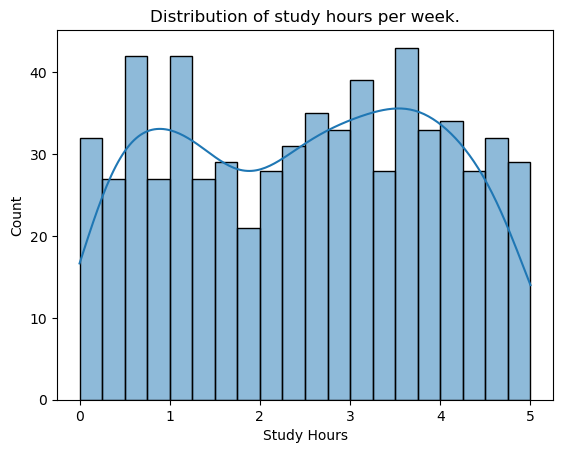

['StudentID', 'Name', 'Gender', 'AttendanceRate', 'StudyHoursPerWeek', 'CurrentGrade', 'ExtracurricularActivities', 'ParentalSupport', 'Exam Scores', 'Study Hours', 'Attendance (%)', 'Online Classes Taken']


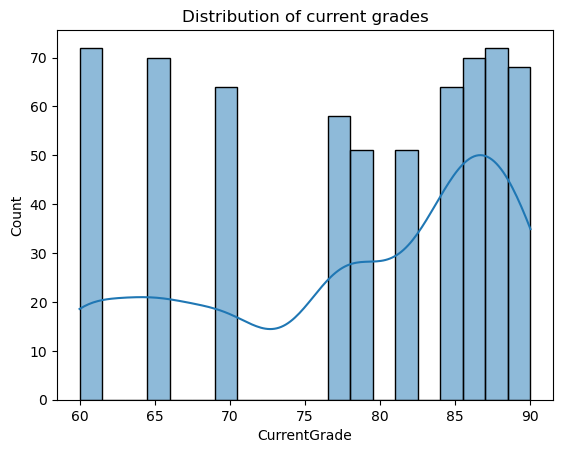

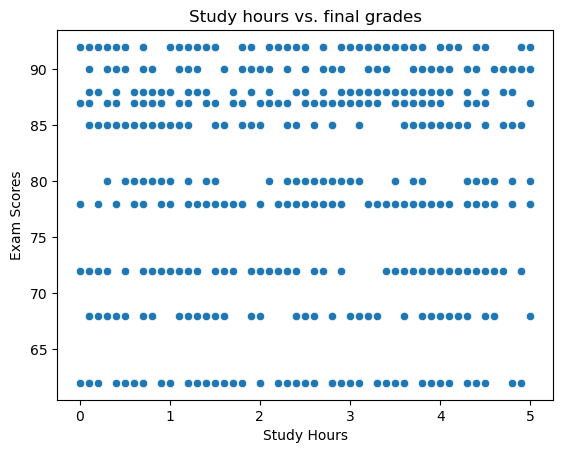

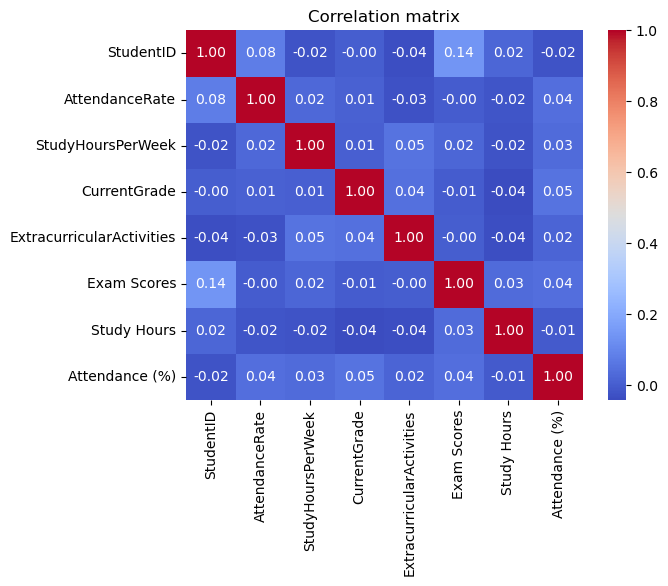

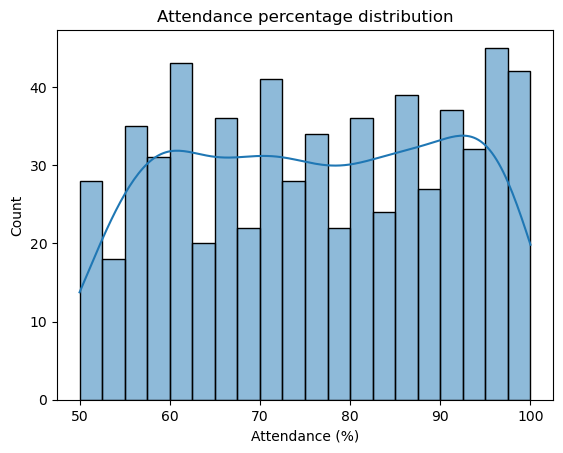

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

data = data[data['Study Hours'] >= 0]

sns.histplot(data['Study Hours'], bins=20, kde=True)
plt.title('Distribution of study hours per week.')
plt.show()

print(data.columns.tolist())

sns.histplot(data['CurrentGrade'], bins=20, kde=True)
plt.title('Distribution of current grades')
plt.show()


sns.scatterplot(x='Study Hours', y='Exam Scores', data=data)
plt.title('Study hours vs. final grades')
plt.show()

correlation_matrix = data.select_dtypes(include='number').corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation matrix')
plt.show()

sns.histplot(data['Attendance (%)'], bins=20, kde=True)
plt.title('Attendance percentage distribution')
plt.show()


# Linear Regression Model

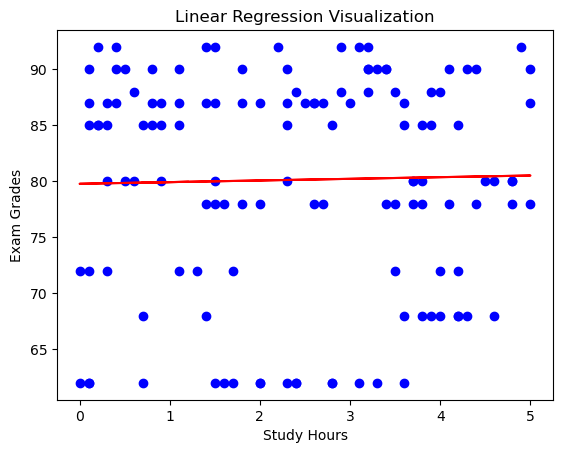

Training set mean squared error:  91.84331354579645
Testing set mean squared error:  95.13172628512568
Training set r2 score:  0.0013940156097935752
Testing set r2 score:  -0.0014277696036915088


In [ ]:
X = data['Study Hours']
y = data['Exam Scores']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.linear_model import Ridge, RidgeCV
import numpy as np

X_train_df = pd.DataFrame(X_train)

X_test_df = pd.DataFrame(X_test)

ridge_cv_model = RidgeCV(alphas = np.random.randint(0,1000,100), cv=10).fit(X_train_df, y_train)

model = Ridge(alpha=ridge_cv_model.alpha_)

model.fit(X_train_df, y_train)

plt.scatter(X_test, y_test, color='blue')
plt.plot(X_train_df, model.predict(X_train_df), color='red')
plt.title('Ridge Linear Regression Visualization')
plt.xlabel('Study Hours')
plt.ylabel('Exam Grades')
plt.show()

from sklearn.metrics import mean_squared_error, r2_score

pred_train = model.predict(X_train_df)

mse_train = mean_squared_error(y_train, pred_train)

print('Training set mean squared error: ', mse_train)

pred_test = model.predict(X_test_df)

mse_test = mean_squared_error(y_test, pred_test)

print('Testing set mean squared error: ', mse_test)

print('Training set r2 score: ', r2_score(y_train, pred_train))
print('Testing set r2 score: ', r2_score(y_test, pred_test))


# Logistic Regression